<img src="../../TPs_Semanal/logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Trabajo Practico de Laboratorio N°1
#### Autor:Nicolas Trombetta
#### Profesor: Mariano Llamedo Soria

El Trabajo tiene como objetivo el diseño e implementacion de un filtro pasabanda tipo chebyshev con ripple de 2.5db en $f_1 \leq f0\leq f_2$, donde $f_0=6kHZ$ con $Q_{BP}=3$. Se establece ademas una banda de rechazo de 15db para $f \leq f_{s_1}=600HZ$ y $f \geq f_{s_2}= 60kHZ$.

Se calcula primero las frecuencias $f_1$ y $f_2$.
$$
Q_{BP}=\frac{f_0}{f_2-f_1}
$$
$$
f_0=\sqrt{f_1f_2}
$$
Resolviendo el sistema de ecuaciones se obtiene que:
$$
f_1=f_0 \frac{\sqrt{4Q_{BP}^2+1}-1}{2Q}
$$
$$
f_2=f_0 \frac{\sqrt{4Q_{BP}^2+1}+1}{2Q}
$$

In [4]:
import numpy as np
from IPython.display import display, Math

f0=6e3
Q=3

f1=f0*(np.sqrt(4*Q**2+1)-1)/(2*Q)
f2=f0*(np.sqrt(4*Q**2+1)+1)/(2*Q)

display(Math(rf"f_1 =  {f1:.4f}"))
display(Math(rf"f_2 =  {f2:.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Se divide el eje de frecuencias del filtro pasa banda por $f_0$ para que la frecuencia central del filtro pasa banda quede normalizada a la unidad.

In [5]:
fs1=600
fs2=60e3

ws1=fs1/f0
ws2=fs2/f0

from IPython.display import display, Math

display(Math(rf"\omega_{{s_1}}  = {ws1:.4f}"))
display(Math(rf"\omega_{{s_2}}  = {ws2:.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Se utiliza la ecuacion de la transformacion $pasa banda \to pasa bajos$, para determinar la frecuencia de corte de la banda de rechazo del prototipo pasa bajos a partir de la frecuencia de corte de la banda de rechazo del filtro pasa banda:
$$
\Omega_s=\frac{Q_{BP}(\omega_s^2−1)}{\omega_s}
$$

**Observacion**:como $\omega_{s_1}\omega_{s_2}=1$ y $\alpha_{min}$ es la misma para ambas frecuencias, producen el mismo valor ($|\Omega_s|$)

In [6]:
ws1_lp=Q*(ws2**2-1)/ws2

display(Math(rf"\Omega_s  = {ws1_lp:.4f}"))

<IPython.core.display.Math object>

La plantilla del filtro pasa bajos que se debe diseñar queda:

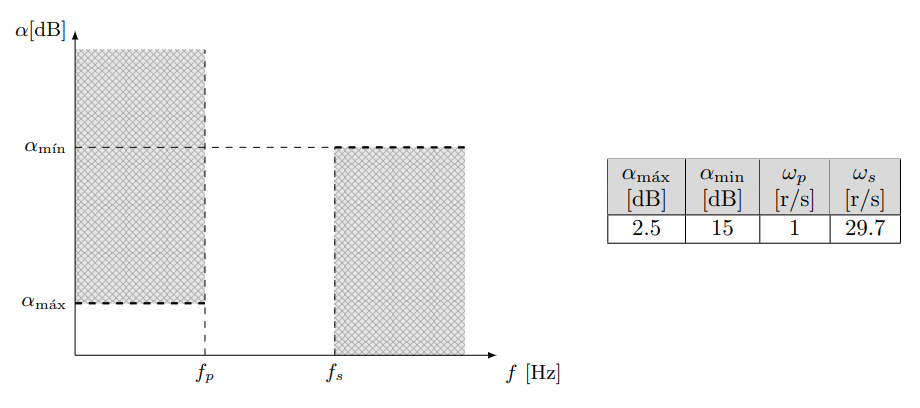

se calcula $\varepsilon^2$ utilizando la siguiente expresion:
$$
\varepsilon^2=10^{\frac{\alpha_{max}}{10}}-1
$$

In [7]:
alfa_max=2.5#db

epsilon2=10**(2.5/10)-1

display(Math(rf"\varepsilon^2={epsilon2:.4f}"))

<IPython.core.display.Math object>

Se busca el orden n minimo que cumpla con la plantilla,es decir $\alpha_s \geq \alpha_{min}$, iterando la siguiente ecuacion:
$$
\alpha_s=10log(1+\varepsilon^2cosh^2(ncosh^{-1}(\Omega_s)))
$$

In [17]:
def alpha_s(n):
    return 10*np.log10(1+epsilon2*np.cosh(n*np.acosh(ws1_lp))**2)

alpha_s_protipo=15#db
n=1

while alpha_s(n)<alpha_s_protipo:
    n+=1

display(Math(rf" n = {n}"))
display(Math(rf" \alpha_s = {alpha_s(n):.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Diseño de filtro chebyshev con $n=1$ y $\varepsilon=0.7783$

$$
|T(\omega)|^2=\frac{1}{1+\varepsilon^2 C_n^2(\omega)}
$$

Recordando que $C_1(\omega)=\omega$:
$$
|T(\omega)|^2=\frac{1}{1+\varepsilon^2 \omega^2}
$$
Reemplazando $\omega=\frac{s}{j}$:
$$
|T(s)|^2=\frac{1}{1-\varepsilon^2 s^2}=\frac{1/\varepsilon^2}{1/\varepsilon^2-s^2}=\frac{1/\varepsilon}{1/\varepsilon-s}\frac{1/\varepsilon}{1/\varepsilon+s}
$$

Se obtiene $T(s)$ quedandose con el polo del semiplano izquierdo:
$$
T(s)=\frac{1/\varepsilon}{1/\varepsilon+s}
$$
Se aplica la transformacion $Pasa Bajos -> Pasa Banda$, para ello se reemplaza $s=Q_{BP}(s+\frac{1}{s})$
$$
T(s)=\frac{1/\varepsilon}{1/\varepsilon+Q_{BP}(s+\frac{1}{s})}=\frac{\frac{s}{\varepsilon Q_{BP}}}{s^2+s\frac{1}{\varepsilon Q_{BP}}+1}
$$

Reemplazando valores:

In [9]:
epsilon=np.sqrt(epsilon2)

Q_sos=epsilon*Q

display(Math(rf"T(s)=\frac{{s{(1/Q_sos):.4f}}}{{s^2+s{(1/Q_sos):.4f}+1}}"))

<IPython.core.display.Math object>

#### Implementacion con MFB

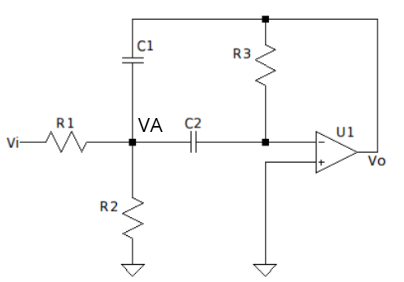



In [10]:

import sympy as sp

S,G1,G2,G3,C1,C2=sp.symbols('S G1 G2 G3 C1 C2')
VA,Vi,Vo=sp.symbols('VA Vi Vo')

eqs=[
    VA*(S*(C1+C2)+G1+G2)-Vo*S*C1-Vi*G1,
    G3*Vo+S*C2*VA
]

sol=sp.solve(eqs,[VA,Vo])

T1 = sp.simplify(sol[Vo]/Vi)


num, den = sp.fraction(T1)
a = sp.Poly(den, S).coeff_monomial(S**2)
num_m = sp.simplify(num / a)
den_m = sp.expand(den / a)
display(Math(rf"T(s)=\frac{{{sp.latex(num_m)}}}{{{sp.latex(den_m)}}}"))

<IPython.core.display.Math object>

Tomando $C_1=C_2=1$, $\omega_0=1$ se obtiene:
$$
\begin{align}
k=-\frac{G_1}{2G_3}\\
Q=\frac{1}{2G_3}\\
1=G_3(G_1+G_2)\\
\end{align}
$$

Despejando los componentes se obtiene que:
$$
\begin{align}
R_1=-\frac{Q}{k}\\
R_2=\frac{Q}{2Q^2+k}\\ \\
R_3=2Q\\
\end{align}
$$

Desnormalizamos los valores para obtener $\omega_0=12000\pi$ y $C_1=C_2=100nF$. Ademas se toma $k$ de forma que $R_1=R_2$

In [18]:
k=-Q_sos**2
c=100e-9 #valor de capacidad objetivo
omega_w=6e3*2*np.pi #frecuencia 

omega_z=1/(c*omega_w)

#Valores de componentes normalizados
R1=-Q_sos/k
R2=Q_sos/(2*Q_sos**2+k)
R3=2*Q_sos

#Desnormalizados
R1=R1*omega_z
R2=R2*omega_z
R3=R3*omega_z

display(Math(rf"k={k:.4f}"))
display(Math(rf"R_1={R1:.4f}"))
display(Math(rf"R_2={R2:.4f}"))
display(Math(rf"R_3={R3:.4f}"))
display(Math(rf"C_1={c}"))
display(Math(rf"C_2={c}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  Como observación de diseño, una mejor elección habría sido emplear un capacitor de menor capacitancia, de modo que la resistencia asociada no resultara tan baja.

Se recalculan los valores de la resistencias para los valores reales de capacitancia

In [12]:
w0=6e3*2*np.pi
C1=97e-9
C2=103e-9

R3=(Q_sos/w0)*((C1+C2)/(C1*C2))
R1=-(R3/k)*(C2/(C1+C2))
R2=R1/(w0**2*C1*C2*R3*R1-1)

display(Math(rf"R_1={R1:.4f}"))
display(Math(rf"R_2={R2:.4f}"))
display(Math(rf"R_3={R3:.4f}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Construccion del circuito
El diseño del circuito esquemático y la placa de circuito impreso (PCB) se realizó utilizando el software KiCad. Posteriormente, se llevó a cabo la fabricación de la placa y el montaje manual de los componentes. Finalmente, se verificó la continuidad de las pistas y la ausencia de cortocircuitos antes de energizar el circuito.

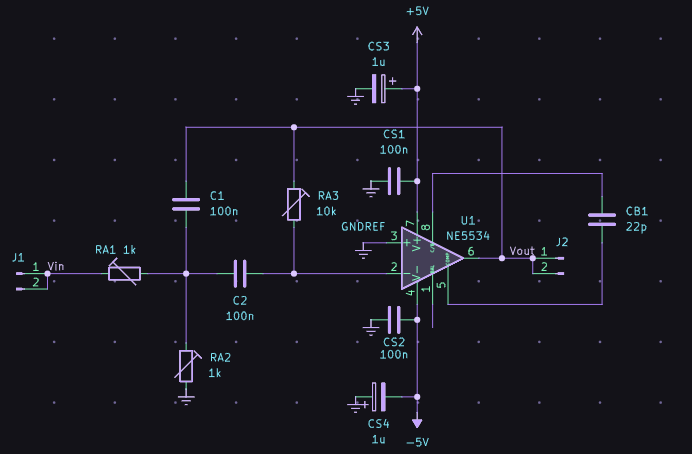

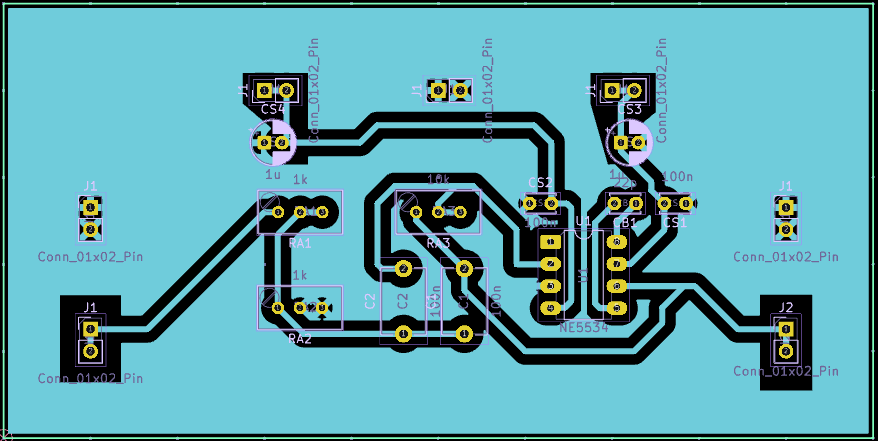

## Laboratorio
  Para la medición de la respuesta del filtro se utilizó un osciloscopio de dos canales, conectando el primer canal a la entrada del circuito y el segundo a la salida. Mediante un generador de señales se aplicó una señal senoidal cuya frecuencia se fue variando de manera gradual. Para cada frecuencia se registraron la amplitud de la señal de salida y el desfase temporal ($\Delta t$) entre las señales de entrada y salida. La respuesta en fase se obtuvo a partir de la diferencia temporal medida entre ambas señales, utilizando la expresión: $ \theta(f) = -2\pi f \Delta t $
donde $\theta$ es el desfase en radianes, $f$ es la frecuencia de la señal de excitación.

### Medidas de Laboratorio con osciloscopio

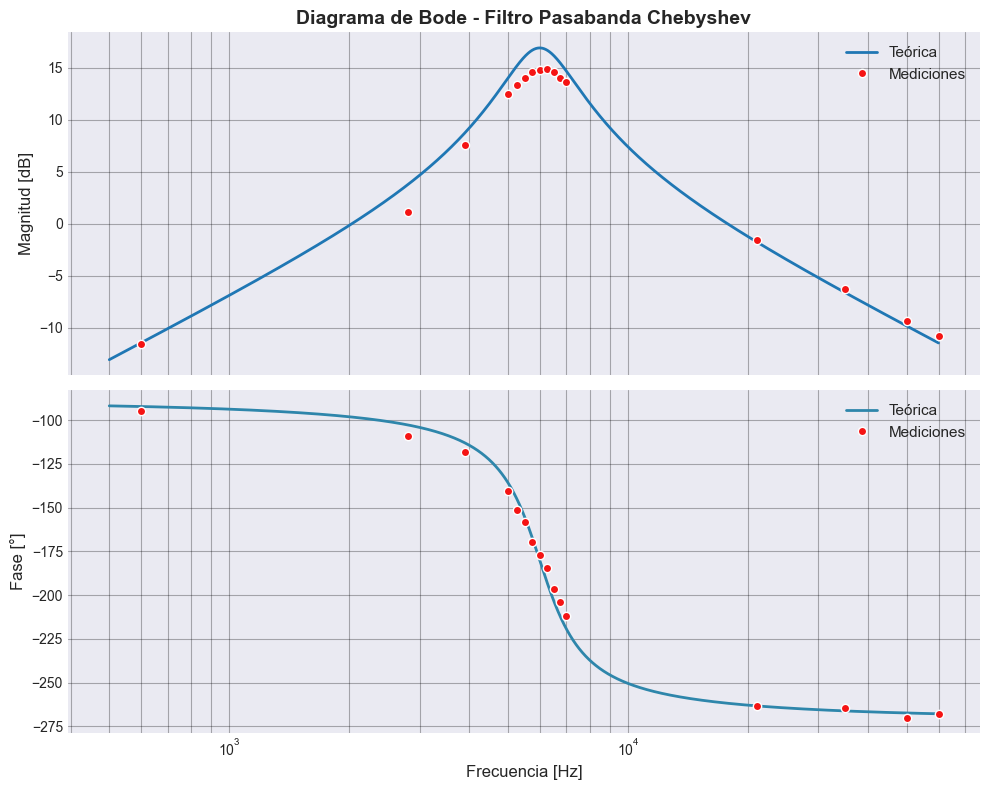

In [13]:
import matplotlib.pyplot as plt
from scipy import signal as sig

plt.style.use('seaborn-v0_8-darkgrid')

num = [k * w0 / Q_sos, 0]
den = [1, w0 / Q_sos, w0**2]
T_esperada = sig.TransferFunction(num, den)
w = np.logspace(np.log10(500 * 2 * np.pi), np.log10(60e3 * 2 * np.pi), 10000)
w, mag, phase = sig.bode(T_esperada, w)

f = np.array([600, 2800, 3900, 5000, 5250, 5500, 5750, 6000, 6250, 6500, 6750, 7000, 21e3, 35e3, 50e3, 60e3])
V_in = np.array([1.58, 1.63, 1.15, 1.62, 1.53, 1.44, 1.34, 1.25, 1.17, 1.13, 1.12, 1.10, 1.24, 1.25, 1.26, 1.26])
V_out = np.array([0.416, 1.85, 2.75, 6.78, 7.11, 7.23, 7.15, 6.88, 6.48, 6.05, 5.65, 5.3, 1.03, 0.61, 0.43, 0.362])
dt = np.array([440, 108, 84, 78, 80, 80, 82, 82, 82, 84, 84, 84, 34.8, 21, 15, 12.4]) * 1e-6

T = 20 * np.log10(V_out / V_in)
fase_medida = f * dt * -360

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(w / (2 * np.pi), mag, label='Teórica', linewidth=2)
ax1.plot(f, T, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax1.set_ylabel('Magnitud [dB]', fontsize=12)
ax1.set_title('Diagrama de Bode - Filtro Pasabanda Chebyshev', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, which='both',color='black', alpha=0.3)
ax1.set_xscale('log')
ax1.tick_params(labelsize=10)

ax2.plot(w / (2 * np.pi), phase, label='Teórica', linewidth=2, color='#2E86AB')
ax2.plot(f, fase_medida, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax2.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax2.set_ylabel('Fase [°]', fontsize=12)
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, which='both',color='black' ,alpha=0.3)
ax2.set_xscale('log')
ax2.tick_params(labelsize=10)

plt.tight_layout()
plt.show()



## Datos medidos con el analizador de audio

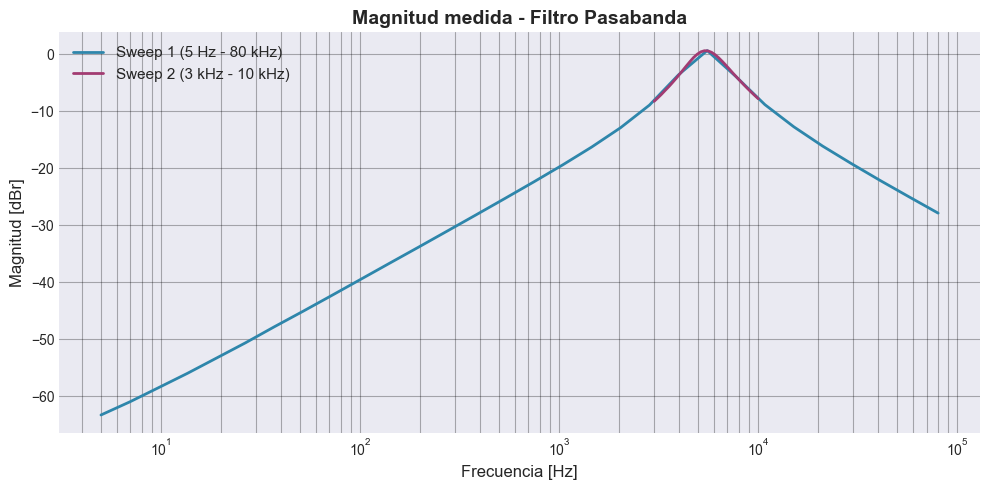

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

def leer_sweep(filename):
    with open(filename) as f:
        lines = f.readlines()
    # Function 1: Frequency vs Frequency (skip 3 header lines)
    f1_start = 3
    f1_end = next(i for i in range(f1_start, len(lines)) if lines[i].strip() == '')
    f1 = pd.read_csv(filename, skiprows=3, nrows=f1_end - f1_start - 1,
                     names=['f_in', 'f_out'])
    # Function 2: Vac vs Frequency
    f2_start = f1_end + 4
    f2 = pd.read_csv(filename, skiprows=f2_start,
                     names=['f', 'dBr'])
    return f1, f2

_, sweep3 = leer_sweep('Sweep Data_3.csv')
_, sweep4 = leer_sweep('Sweep Data_4.csv')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sweep3['f'], sweep3['dBr'], label='Sweep 1 (5 Hz - 80 kHz)', linewidth=2, color='#2E86AB')
ax.plot(sweep4['f'], sweep4['dBr'], label='Sweep 2 (3 kHz - 10 kHz)', linewidth=2, color='#A23B72')
ax.set_xscale('log')
ax.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax.set_ylabel('Magnitud [dBr]', fontsize=12)
ax.set_title('Magnitud medida - Filtro Pasabanda', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, which='both',color='black', alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion
En este trabajo se completó el ciclo de diseño de un filtro activo: a partir de la plantilla normalizada se obtuvo el prototipo pasabajos Chebyshev de orden $n=1$ (con el cual se cumple holgadamente el requisito, $\alpha_s \approx 28\,dB > 15\,dB$), se aplicó la transformación pasabajos → pasabanda y se implementó el resultado —un pasabanda de segundo orden con $f_0 = 6\,kHz$ y $Q_{BP} = 3$ con topología múltiple realimentada (MFB).

Las mediciones con osciloscopio mostraron buen acuerdo con la respuesta teórica dentro de la banda de paso: la ganancia máxima medida ronda los 14–15 dB cerca de $f_0$ y el ancho de banda es consistente con el Q de diseño. La fase estimada a partir del desfase temporal coincide con la curva teórica, incluyendo el corrimiento de 180° propio de la configuración inversora del MFB en la frecuencia central. El barrido con analizador de espectro confirmó la forma característica del pasabanda en toda la escala de frecuencias.

Como mejoras futuras se proponen: utilizar resistencias de mayor valor adoptando capacitores de menor capacidad, de modo de llevar las impedancias a la escala de kΩ y minimizar el efecto de carga del generador.
